# RandomForest Optimization

**Goal:** Find the best RF configuration for live trading.

1. Feature selection — forward selection with RF to find optimal N
2. Hyperparameter tuning on best features
3. Strategy comparison (scaling-in variants + confidence filtering)
4. Equity curve on newest candles (forward test)

**Data:** `data/latest_features.jsonl` for training, `collection.db` for forward test.

In [1]:
import json
import random
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../data/latest_features.jsonl")
DB_PATH = Path("../data/collection.db")
MAX_BID = 0.85
WARM_UP = 21

## 1. Load data and train/val split

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

# Time-based split
candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])
val_ids = set(candle_ids[split_idx:])

df_train = df[df["candle_id"].isin(train_ids)]
df_val = df[df["candle_id"].isin(val_ids)]

print(f"All features: {len(all_feat_cols)}")
print(f"Train: {len(df_train):,} rows, {df_train['candle_id'].nunique()} candles")
print(f"Val:   {len(df_val):,} rows, {df_val['candle_id'].nunique()} candles")

All features: 60
Train: 42,925 rows, 882 candles
Val:   10,452 rows, 221 candles


## 2. Individual feature ranking with RF

In [3]:
scaler = StandardScaler()
X_train_all = scaler.fit_transform(df_train[all_feat_cols].values)
y_train = df_train["target"].values
X_val_all = scaler.transform(df_val[all_feat_cols].values)
y_val = df_val["target"].values

# Train full RF to get feature importances
rf_full = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_full.fit(X_train_all, y_train)
full_acc = accuracy_score(y_val, rf_full.predict(X_val_all))
print(f"RF with all {len(all_feat_cols)} features: {full_acc * 100:.1f}% val accuracy")

# Feature importances
importances = rf_full.feature_importances_
feat_imp = sorted(zip(all_feat_cols, importances, strict=False), key=lambda x: -x[1])

print(f"\n{'Feature':<35} {'Importance':>10}")
print("-" * 48)
for name, imp in feat_imp:
    print(f"{name:<35} {imp:>10.4f}")

RF with all 60 features: 74.5% val accuracy

Feature                             Importance
------------------------------------------------
down_risk_reward                        0.1106
up_risk_reward                          0.0799
btc_move_from_open                      0.0611
down_implied_probability                0.0593
rr_spread                               0.0492
up_implied_probability                  0.0417
down_token_velocity                     0.0331
up_spread_level                         0.0326
up_token_velocity                       0.0280
btc_velocity                            0.0220
adx                                     0.0209
time_of_day_cos                         0.0202
volume_momentum                         0.0194
ma_crossover                            0.0187
regime_score                            0.0181
stochastic_k                            0.0181
return_autocorrelation                  0.0180
conviction_score                        0.0178
multi_candle_

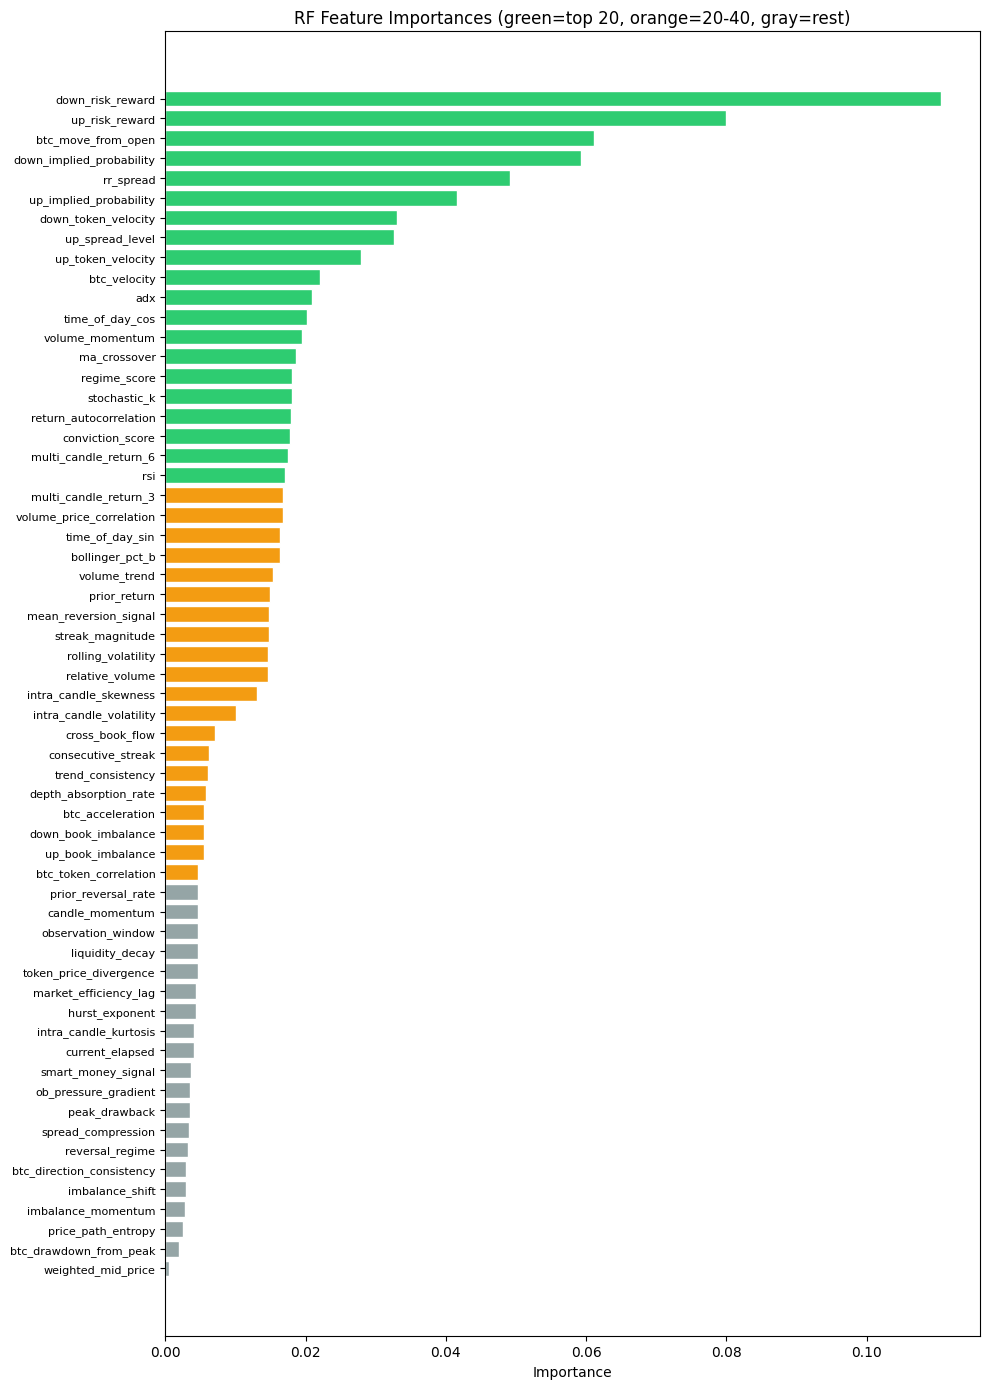

In [4]:
# Bar chart of feature importances
names = [f[0] for f in feat_imp]
imps = [f[1] for f in feat_imp]

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#2ecc71" if i < 20 else "#f39c12" if i < 40 else "#95a5a6" for i in range(len(names))]
ax.barh(range(len(names)), imps, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Importance")
ax.set_title("RF Feature Importances (green=top 20, orange=20-40, gray=rest)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Find optimal feature count using importances


In [5]:
# Test top-N features by importance (much faster than forward selection)
ranked_features = [name for name, _ in feat_imp]
ranked_indices = [all_feat_cols.index(name) for name in ranked_features]

top_n_results = []
print(f"{'Top N':<8} {'Val Acc':>8} {'Per-candle':>12}")
print("-" * 32)

for n in list(range(5, len(all_feat_cols) + 1, 5)) + [len(all_feat_cols)]:
    idx = ranked_indices[:n]
    rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
    rf.fit(X_train_all[:, idx], y_train)
    snap_acc = accuracy_score(y_val, rf.predict(X_val_all[:, idx]))
    # Per-candle
    probs = rf.predict_proba(X_val_all[:, idx])[:, 1]
    correct = 0
    total = 0
    for cid in df_val["candle_id"].unique():
        cmask = df_val["candle_id"] == cid
        y_c = df_val.loc[cmask, "target"].values[0]
        vote = 1 if probs[cmask.values].mean() >= 0.5 else 0
        total += 1
        if vote == y_c:
            correct += 1
    candle_acc = correct / total
    top_n_results.append((n, snap_acc, candle_acc))
    print(f"  {n:<6} {snap_acc * 100:>7.1f}% {candle_acc * 100:>11.1f}%")

# Find best N by per-candle accuracy
best_n, best_snap, best_candle = max(top_n_results, key=lambda x: x[2])
print(f"\nBest: top {best_n} features → {best_candle * 100:.1f}% per-candle accuracy")

optimal_names = ranked_features[:best_n]
print(f"Optimal features: {optimal_names}")

Top N     Val Acc   Per-candle
--------------------------------


  5         75.5%        86.0%


  10        75.3%        86.4%


  15        74.9%        86.4%


  20        73.3%        88.2%


...

  45        74.1%        84.6%


  50        74.1%        85.5%


  55        74.2%        85.5%


  60        74.5%        85.5%


  60        74.5%        85.5%

Best: top 20 features → 88.2% per-candle accuracy
Optimal features: ['down_risk_reward', 'up_risk_reward', 'btc_move_from_open', 'down_implied_probability', 'rr_spread', 'up_implied_probability', 'down_token_velocity', 'up_spread_level', 'up_token_velocity', 'btc_velocity', 'adx', 'time_of_day_cos', 'volume_momentum', 'ma_crossover', 'regime_score', 'stochastic_k', 'return_autocorrelation', 'conviction_score', 'multi_candle_return_6', 'rsi']


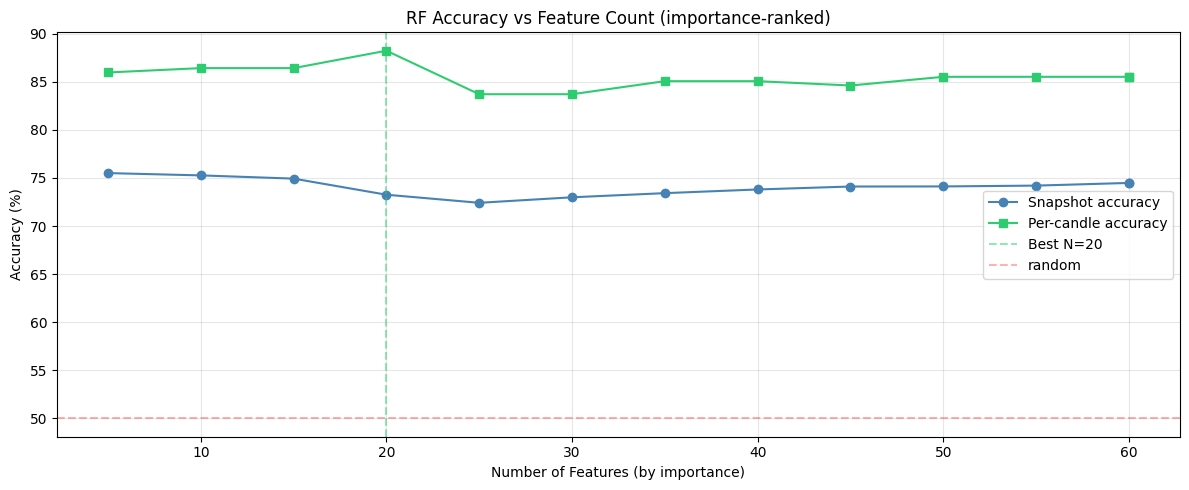

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ns = [r[0] for r in top_n_results]
snap_accs = [r[1] * 100 for r in top_n_results]
candle_accs = [r[2] * 100 for r in top_n_results]

ax.plot(ns, snap_accs, "o-", label="Snapshot accuracy", color="steelblue")
ax.plot(ns, candle_accs, "s-", label="Per-candle accuracy", color="#2ecc71")
ax.axvline(best_n, color="#2ecc71", linestyle="--", alpha=0.5, label=f"Best N={best_n}")
ax.axhline(50, color="red", linestyle="--", alpha=0.3, label="random")
ax.set_xlabel("Number of Features (by importance)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("RF Accuracy vs Feature Count (importance-ranked)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Train optimized RF and evaluate

In [7]:
# Use optimal features
feat_cols = optimal_names
feat_indices = [all_feat_cols.index(f) for f in feat_cols]

X_tr = X_train_all[:, feat_indices]
X_va = X_val_all[:, feat_indices]

rf_opt = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_opt.fit(X_tr, y_train)

val_acc = accuracy_score(y_val, rf_opt.predict(X_va))
print(f"Optimized RF ({len(feat_cols)} features): {val_acc * 100:.1f}% val accuracy")
print("\nValidation report:")
print(classification_report(y_val, rf_opt.predict(X_va), target_names=["DOWN", "UP"]))

# Per-candle accuracy
probs_val = rf_opt.predict_proba(X_va)[:, 1]
correct, total = 0, 0
for cid in df_val["candle_id"].unique():
    cmask = df_val["candle_id"] == cid
    idx = cmask.values
    y_c = df_val.loc[cmask, "target"].values[0]
    vote = 1 if probs_val[idx].mean() >= 0.5 else 0
    total += 1
    if vote == y_c:
        correct += 1
print(f"\nPer-candle accuracy: {correct}/{total} = {correct / total * 100:.1f}%")

Optimized RF (20 features): 73.3% val accuracy

Validation report:
              precision    recall  f1-score   support

        DOWN       0.79      0.68      0.73      5541
          UP       0.69      0.79      0.74      4911

    accuracy                           0.73     10452
   macro avg       0.74      0.74      0.73     10452
weighted avg       0.74      0.73      0.73     10452


Per-candle accuracy: 195/221 = 88.2%


### Confidence calibration on validation set

Confidence              N   Win Rate
--------------------------------------
  [0.50-0.55)       1192      50.5%
  [0.55-0.60)       1240      52.4%
  [0.60-0.65)       1068      57.2%
  [0.65-0.70)       1013      55.4%
  [0.70-0.80)       1585      77.0%
  [0.80-0.90)       1464      85.9%
  [0.90-1.01)       2890      95.3%


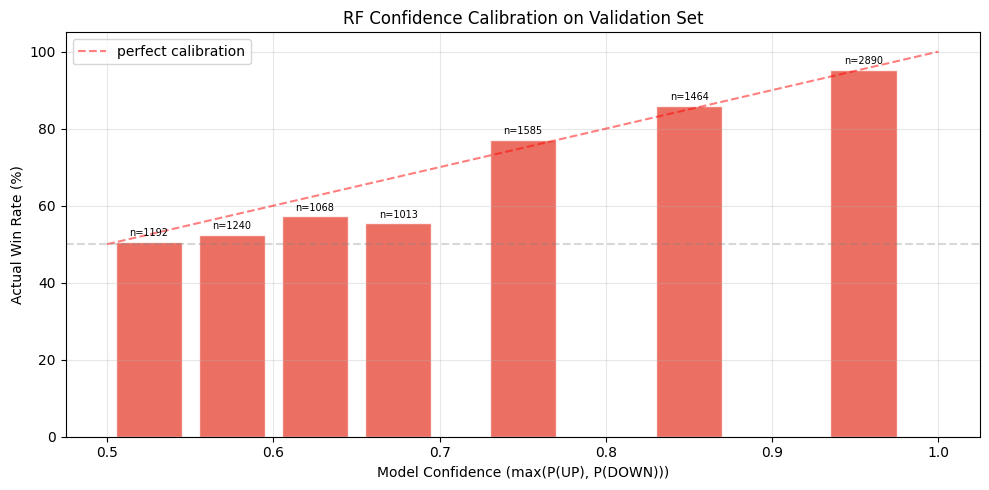

In [8]:
# Confidence = max(P(UP), P(DOWN))
confidence_val = np.maximum(probs_val, 1.0 - probs_val)
preds_val = (probs_val >= 0.5).astype(int)
correct_val = preds_val == y_val

bins = [
    (0.50, 0.55),
    (0.55, 0.60),
    (0.60, 0.65),
    (0.65, 0.70),
    (0.70, 0.80),
    (0.80, 0.90),
    (0.90, 1.01),
]
cal_data = []
for lo, hi in bins:
    cmask = (confidence_val >= lo) & (confidence_val < hi)
    if cmask.sum() == 0:
        continue
    wr = correct_val[cmask].mean()
    cal_data.append({"range": f"[{lo:.2f}-{hi:.2f})", "n": int(cmask.sum()), "win_rate": wr, "mid": (lo + hi) / 2})

print(f"{'Confidence':<18} {'N':>6} {'Win Rate':>10}")
print("-" * 38)
for d in cal_data:
    print(f"  {d['range']:<16} {d['n']:>5} {d['win_rate'] * 100:>9.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
x = [d["mid"] for d in cal_data]
wr = [d["win_rate"] * 100 for d in cal_data]
ns = [d["n"] for d in cal_data]
ax.bar(x, wr, width=0.04, color="#e74c3c", edgecolor="white", alpha=0.8)
ax.plot([0.5, 1.0], [50, 100], "r--", alpha=0.5, label="perfect calibration")
ax.axhline(50, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Model Confidence (max(P(UP), P(DOWN)))")
ax.set_ylabel("Actual Win Rate (%)")
ax.set_title("RF Confidence Calibration on Validation Set")
ax.legend()
for xi, wi, ni in zip(x, wr, ns, strict=True):
    ax.text(xi, wi + 1.5, f"n={ni}", ha="center", fontsize=7)
ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Load newest candles for forward test

In [9]:
# Train on ALL JSONL data with optimal features
scaler_final = StandardScaler()
X_all = scaler_final.fit_transform(df[feat_cols].values)
y_all = df["target"].values

rf_final = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_final.fit(X_all, y_all)

max_train_ts = df["timestamp"].max()
print(f"Trained on {df['candle_id'].nunique()} candles ({len(df):,} rows)")

# Load new candles from DB
conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time", conn)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}", conn
)
conn.close()
prior_candles_df = prior_candles_df.sort_values("start_time")

# Build prior candles
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

# Compute features for new candles
all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )
    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue
    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )
    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_eval = pd.DataFrame(all_rows)
df_eval["target"] = (df_eval["outcome"] == "UP").astype(int)
df_eval[feat_cols] = df_eval[feat_cols].fillna(0.0)

print(f"\nNew candles: {df_eval['candle_id'].nunique()}")
print(f"Rows: {len(df_eval):,}")
if len(df_eval) == 0:
    print("WARNING: No new candles. Run collector longer or rebuild features.")

Trained on 1103 candles (53,377 rows)


Computing features:   0%|          | 0/74 [00:00<?, ?it/s]

Computing features:  20%|██        | 15/74 [00:00<00:00, 145.99it/s]

Computing features:  41%|████      | 30/74 [00:00<00:00, 146.97it/s]

Computing features:  61%|██████    | 45/74 [00:00<00:00, 146.27it/s]

Computing features:  81%|████████  | 60/74 [00:00<00:00, 146.51it/s]

Computing features: 100%|██████████| 74/74 [00:00<00:00, 146.60it/s]


New candles: 74
Rows: 3,451


## 6. Build per-candle predictions

In [10]:
all_cd = []

for cid in df_eval["candle_id"].unique():
    snap_rows = df_eval[df_eval["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler_final.transform(snap_rows[feat_cols].values)
    probs = rf_final.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)
    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values
    elapsed = snap_rows["elapsed_pct"].values

    sd = [
        {
            "tick": i,
            "elapsed_pct": elapsed[i],
            "pred": int(preds[i]),
            "prob": float(probs[i]),
            "up_ask": up_asks[i],
            "down_ask": down_asks[i],
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print(f"Built predictions for {len(all_cd)} candles")

Built predictions for 74 candles


## 7. Scaling-in strategies + confidence filtering

In [11]:
def run_scaling(name, entry_points, bet_per_entry=10.0, min_confidence=0.0):
    bal = 1000.0
    history = [bal]
    total_bets, total_wins, candles_entered, candles_skipped = 0, 0, 0, 0

    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []
        first_direction = None

        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= prev_tick for prev_tick, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(n_c)):
                    continue
                confidence = max(sd[i]["prob"], 1.0 - sd[i]["prob"])
                if confidence < min_confidence:
                    continue
                direction = sd[i]["pred"]
                if first_direction is None:
                    first_direction = direction
                elif direction != first_direction:
                    break
                ask = sd[i]["up_ask"] if direction == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, direction, ask))
                break

        if not entries:
            candles_skipped += 1
            continue
        candles_entered += 1
        for _, direction, ask in entries:
            if bal < bet_per_entry:
                break
            total_bets += 1
            if direction == truth:
                bal += (bet_per_entry / ask) * (1.0 - ask)
                total_wins += 1
            else:
                bal -= bet_per_entry
        history.append(bal)

    wr = total_wins / total_bets if total_bets > 0 else 0
    avg_entries = total_bets / candles_entered if candles_entered > 0 else 0
    return {
        "name": name,
        "balance": bal,
        "history": history,
        "total_bets": total_bets,
        "candles_entered": candles_entered,
        "candles_skipped": candles_skipped,
        "wins": total_wins,
        "win_rate": wr,
        "avg_entries": avg_entries,
        "return": (bal - 1000) / 1000 * 100,
    }

In [12]:
strategies = [
    # Baseline
    ("1x e5%", [(0.05, 3)], 0.0),
    ("1x e5% conf>0.6", [(0.05, 3)], 0.6),
    ("1x e5% conf>0.7", [(0.05, 3)], 0.7),
    # 2x scaling
    ("2x e5%+e50%", [(0.05, 3), (0.50, 3)], 0.0),
    ("2x e5%+e50% conf>0.6", [(0.05, 3), (0.50, 3)], 0.6),
    ("2x e5%+e50% conf>0.7", [(0.05, 3), (0.50, 3)], 0.7),
    # Delayed entry (RF better later)
    ("1x e20%", [(0.20, 3)], 0.0),
    ("1x e30%", [(0.30, 3)], 0.0),
    ("2x e20%+e50%", [(0.20, 3), (0.50, 3)], 0.0),
    ("2x e30%+e60%", [(0.30, 3), (0.60, 3)], 0.0),
    ("2x e30%+e60% conf>0.6", [(0.30, 3), (0.60, 3)], 0.6),
    ("2x e40%+e65%", [(0.40, 3), (0.65, 3)], 0.0),
    ("2x e40%+e65% conf>0.6", [(0.40, 3), (0.65, 3)], 0.6),
]

results = []
print(f"{'Strategy':<30} {'Bets':>5} {'Cndl':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 80)

for name, eps, conf in strategies:
    r = run_scaling(name, eps, min_confidence=conf)
    peak = r["history"][0]
    max_dd = 0
    for h in r["history"]:
        if h > peak:
            peak = h
        dd = (peak - h) / peak
        if dd > max_dd:
            max_dd = dd
    r["max_dd"] = max_dd
    results.append(r)
    print(
        f"{r['name']:<30} {r['total_bets']:>5} {r['candles_entered']:>5} "
        f"{r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return']:>+7.1f}% {max_dd * 100:>6.1f}%"
    )

Strategy                        Bets  Cndl     WR    Balance   Return   MaxDD
--------------------------------------------------------------------------------
1x e5%                            74    74  51.4% $   925.46    -7.5%   10.0%
1x e5% conf>0.6                   74    74  55.4% $   910.20    -9.0%   13.0%
1x e5% conf>0.7                   72    72  68.1% $   974.66    -2.5%    8.3%
2x e5%+e50%                      107    74  53.3% $   857.74   -14.2%   17.9%
2x e5%+e50% conf>0.6             108    74  57.4% $   860.01   -14.0%   20.4%
2x e5%+e50% conf>0.7             112    72  67.9% $   931.71    -6.8%   12.6%
1x e20%                           74    74  50.0% $   816.35   -18.4%   19.6%
1x e30%                           70    70  61.4% $   920.20    -8.0%   10.5%
2x e20%+e50%                     111    74  49.5% $   693.98   -30.6%   32.7%
2x e30%+e60%                     105    70  61.0% $   861.91   -13.8%   17.6%
2x e30%+e60% conf>0.6            104    70  67.3% $   919.04 

## 8. Equity curves

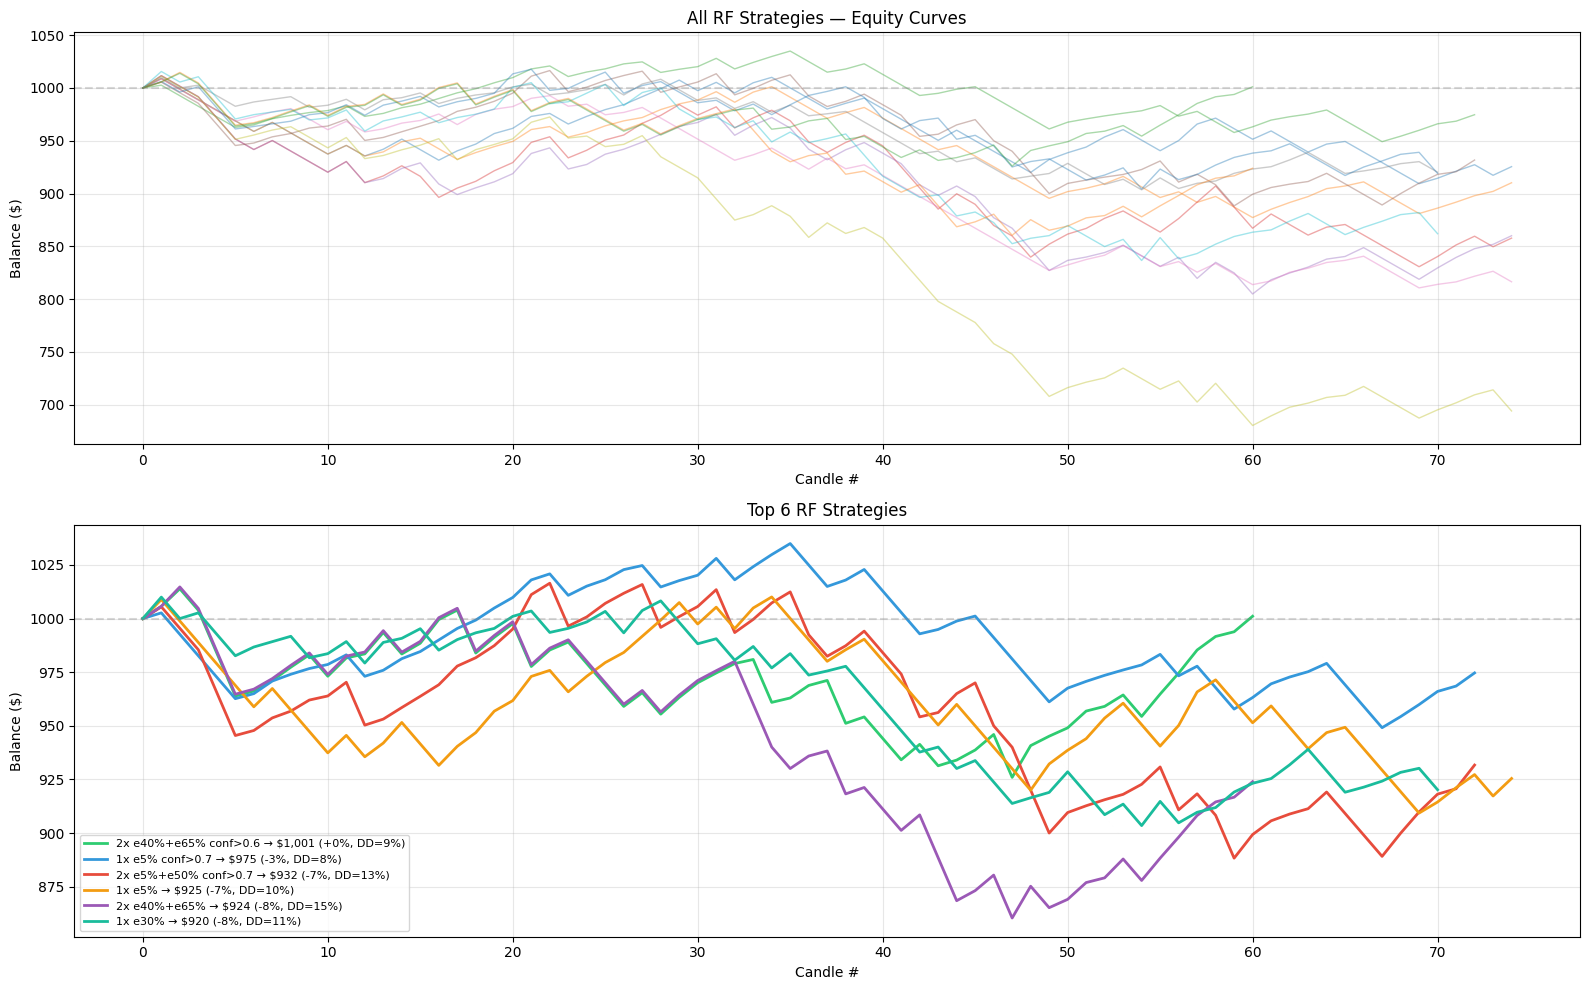

In [13]:
# Top performers by return
top = sorted(results, key=lambda r: -r["balance"])[:6]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12", "#9b59b6", "#1abc9c"]

# All strategies
for r in results:
    axes[0].plot(r["history"], alpha=0.4, linewidth=1)
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Candle #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("All RF Strategies — Equity Curves")
axes[0].grid(alpha=0.3)

# Top performers
for r, color in zip(top, colors, strict=False):
    axes[1].plot(
        r["history"],
        label=f"{r['name']} → ${r['balance']:,.0f} ({r['return']:+.0f}%, DD={r['max_dd'] * 100:.0f}%)",
        color=color,
        linewidth=2,
    )
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Candle #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 6 RF Strategies")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Risk-adjusted comparison

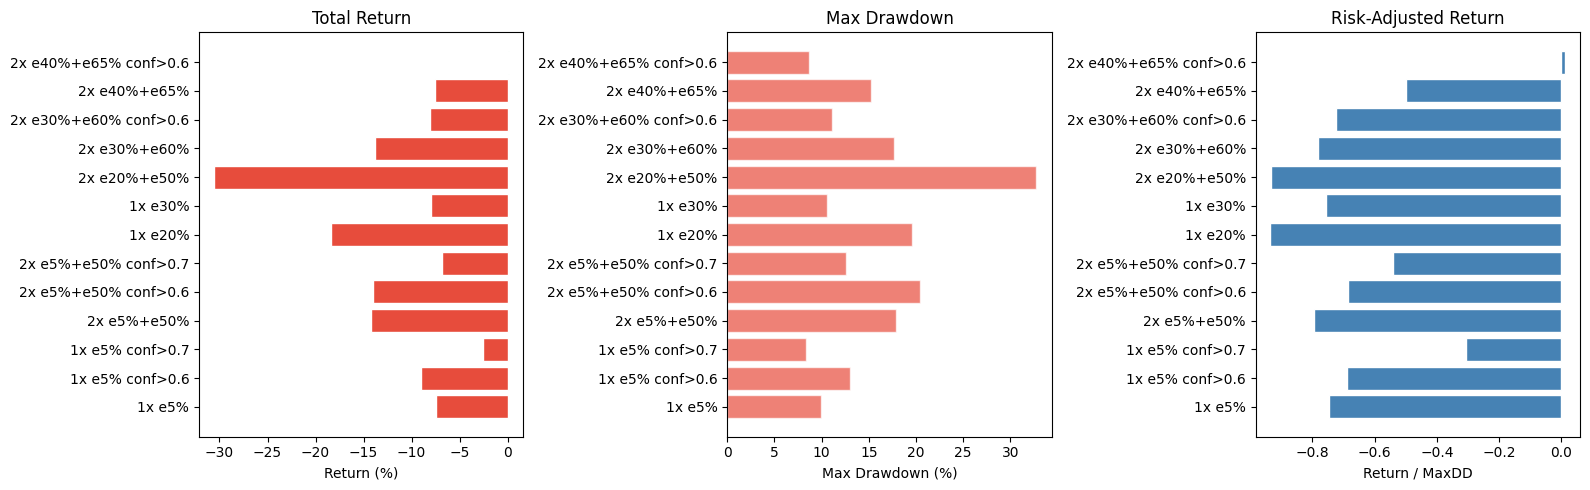

Best risk-adjusted: 2x e40%+e65% conf>0.6 (return/DD = 0.01)
Best total return:  2x e40%+e65% conf>0.6 (+0.1%, DD=8.7%)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = [r["name"] for r in results]

rets = [r["return"] for r in results]
axes[0].barh(names, rets, color=["#2ecc71" if r > 0 else "#e74c3c" for r in rets], edgecolor="white")
axes[0].set_xlabel("Return (%)")
axes[0].set_title("Total Return")

dds = [r["max_dd"] * 100 for r in results]
axes[1].barh(names, dds, color="#e74c3c", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Max Drawdown (%)")
axes[1].set_title("Max Drawdown")

ratios = [r["return"] / (r["max_dd"] * 100 + 0.01) for r in results]
axes[2].barh(names, ratios, color="steelblue", edgecolor="white")
axes[2].set_xlabel("Return / MaxDD")
axes[2].set_title("Risk-Adjusted Return")

plt.tight_layout()
plt.show()

best_ratio = max(results, key=lambda r: r["return"] / (r["max_dd"] * 100 + 0.01))
best_return = max(results, key=lambda r: r["return"])
print(
    f"Best risk-adjusted: {best_ratio['name']} (return/DD = {best_ratio['return'] / (best_ratio['max_dd'] * 100 + 0.01):.2f})"
)
print(
    f"Best total return:  {best_return['name']} ({best_return['return']:+.1f}%, DD={best_return['max_dd'] * 100:.1f}%)"
)

## 10. Conclusion

Results above are on forward-test candles (never seen during training). See the strategy table and equity curves for recommendations. Re-run after collecting more data for more robust conclusions.